In [3]:
import cv2
from ultralytics import YOLO

# Load your trained YOLOv11 model
model = YOLO(r"C:\z_Learn\miraj_pandas\Deep Learning\YOLO\best.pt")
image_path = r"C:\z_Learn\miraj_pandas\Deep Learning\YOLO\test_image.jpg"
results = model(image_path)


image 1/1 C:\z_Learn\miraj_pandas\Deep Learning\YOLO\test_image.jpg: 512x640 1 mask, 108.9ms
Speed: 4.3ms preprocess, 108.9ms inference, 1.9ms postprocess per image at shape (1, 3, 512, 640)


In [6]:
print(results[0].boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.])
conf: tensor([0.9300])
data: tensor([[243.3582, 147.0611, 343.2969, 223.5414,   0.9300,   0.0000]])
id: None
is_track: False
orig_shape: (480, 638)
shape: torch.Size([1, 6])
xywh: tensor([[293.3276, 185.3012,  99.9387,  76.4803]])
xywhn: tensor([[0.4598, 0.3860, 0.1566, 0.1593]])
xyxy: tensor([[243.3582, 147.0611, 343.2969, 223.5414]])
xyxyn: tensor([[0.3814, 0.3064, 0.5381, 0.4657]])


In [13]:
model.names

{0: 'mask', 1: 'no mask', 2: 'phone'}

In [14]:
prediction_class = int(results[0].boxes.cls[0])
confidence = float(results[0].boxes.conf[0])
print(f"Prediction Class: {model.names[prediction_class]}, Confidence: {confidence:.2f}")   

Prediction Class: mask, Confidence: 0.93


### we can also make the boxes by ourselves with boxes info using open cv 


image 1/1 C:\z_Learn\miraj_pandas\Deep Learning\YOLO\test_image.jpg: 512x640 1 mask, 91.1ms
Speed: 3.7ms preprocess, 91.1ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)


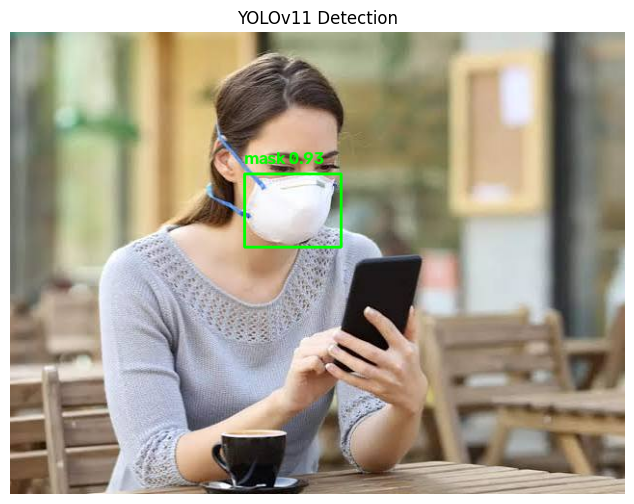

In [19]:
import matplotlib.pyplot as plt

model = YOLO(r"C:\z_Learn\miraj_pandas\Deep Learning\YOLO\best.pt")

image_path = r"C:\z_Learn\miraj_pandas\Deep Learning\YOLO\test_image.jpg"

results = model(image_path)

frame = cv2.imread(image_path)

for box in results[0].boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # Draw bounding box
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Draw label
    label = f"{class_name} {confidence:.2f}"
    cv2.putText(
        frame,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

# Convert BGR to RGB for Matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("YOLOv11 Detection")
plt.show()